# Task 1: Simulation and Sensitivity Analysis of Chaotic Systems
**Author:** Ibrahim Hanafy  
**Objective:** Simulate discrete and continuous chaotic systems, construct bifurcation diagrams, and perform sensitivity analysis on the Lorenz system.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import os, time

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
    'font.size': 11
})

FIGURES_DIR = '../Figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

def save(name):
    plt.savefig(f'{FIGURES_DIR}/{name}.png')
    print(f'Saved {name}.png')

---
# Part A — Discrete Chaotic Systems
## A.1 Logistic Map
$$x_{n+1} = r \cdot x_n \cdot (1 - x_n)$$

| Setting | Value |
|---|---|
| State variable | $x \in [0, 1]$ |
| Control parameter | $r$ (growth rate) |
| Parameter range | $r \in [2.5, 4.0]$ |
| Initial condition | $x_0 = 0.5$ |
| Iterations | 1000 (discard first 500) |

Saved logistic_timeseries.png


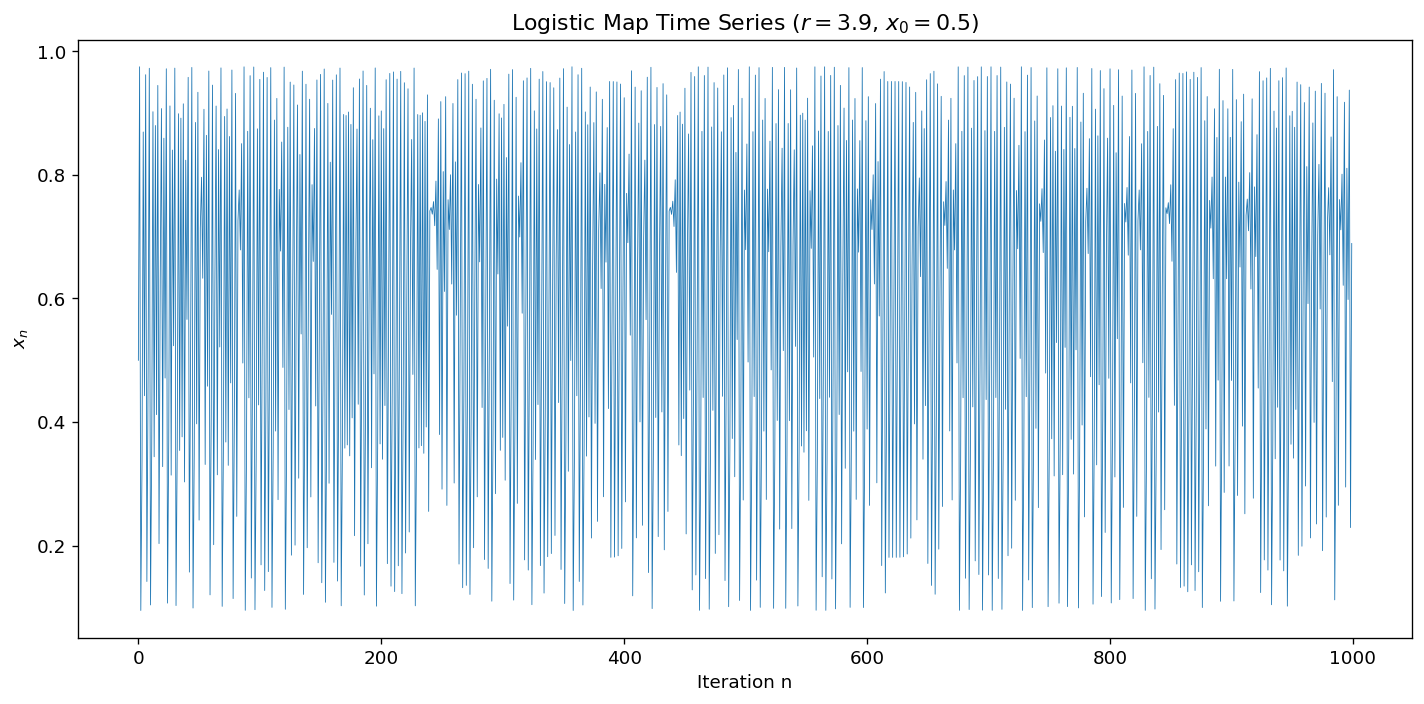

In [2]:
def logistic_map(r, x0, n):
    x = np.empty(n)
    x[0] = x0
    for i in range(1, n):
        x[i] = r * x[i-1] * (1 - x[i-1])
    return x

x = logistic_map(r=3.9, x0=0.5, n=1000)

plt.figure()
plt.plot(x, linewidth=0.5)
plt.xlabel('Iteration n'); plt.ylabel(r'$x_n$')
plt.title(r'Logistic Map Time Series ($r=3.9$, $x_0=0.5$)')
plt.tight_layout(); save('logistic_timeseries'); plt.show()

## A.2 Logistic Map — Bifurcation Diagram
Sweep $r \in [2.5, 4.0]$, iterate all $r$-values simultaneously (vectorized), discard transient.

Saved logistic_bifurcation.png


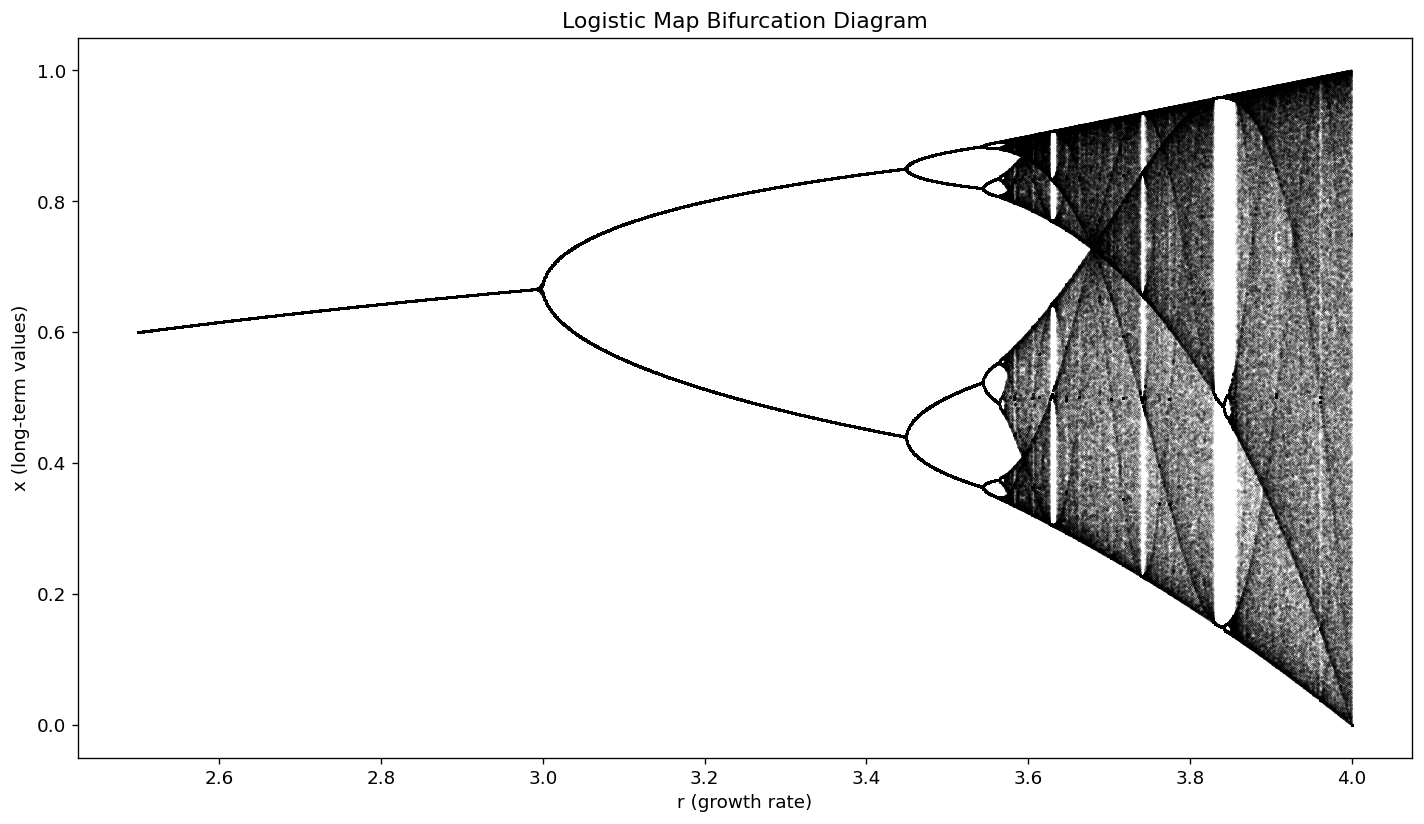

2.7s


In [3]:
t0 = time.time()
r_vals = np.linspace(2.5, 4.0, 2000)
x = 0.5 * np.ones_like(r_vals)
discard, keep = 500, 500

for _ in range(discard):
    x = r_vals * x * (1 - x)

r_pts = np.empty(keep * len(r_vals))
x_pts = np.empty(keep * len(r_vals))
for i in range(keep):
    x = r_vals * x * (1 - x)
    r_pts[i*len(r_vals):(i+1)*len(r_vals)] = r_vals
    x_pts[i*len(r_vals):(i+1)*len(r_vals)] = x

plt.figure(figsize=(12, 7))
plt.scatter(r_pts, x_pts, s=0.1, c='black', marker='.', alpha=0.5)
plt.xlabel('r (growth rate)'); plt.ylabel('x (long-term values)')
plt.title('Logistic Map Bifurcation Diagram')
plt.tight_layout(); save('logistic_bifurcation'); plt.show()
print(f'{time.time()-t0:.1f}s')

## A.3 Hénon Map
$$x_{n+1} = 1 - a \cdot x_n^2 + y_n, \qquad y_{n+1} = b \cdot x_n$$

| Setting | Value |
|---|---|
| State variables | $(x, y)$ |
| Parameters | $a = 1.4,\ b = 0.3$ |
| Initial condition | $(0, 0)$ |
| Iterations | 10000 (discard first 500) |

Saved henon_attractor_timeseries.png


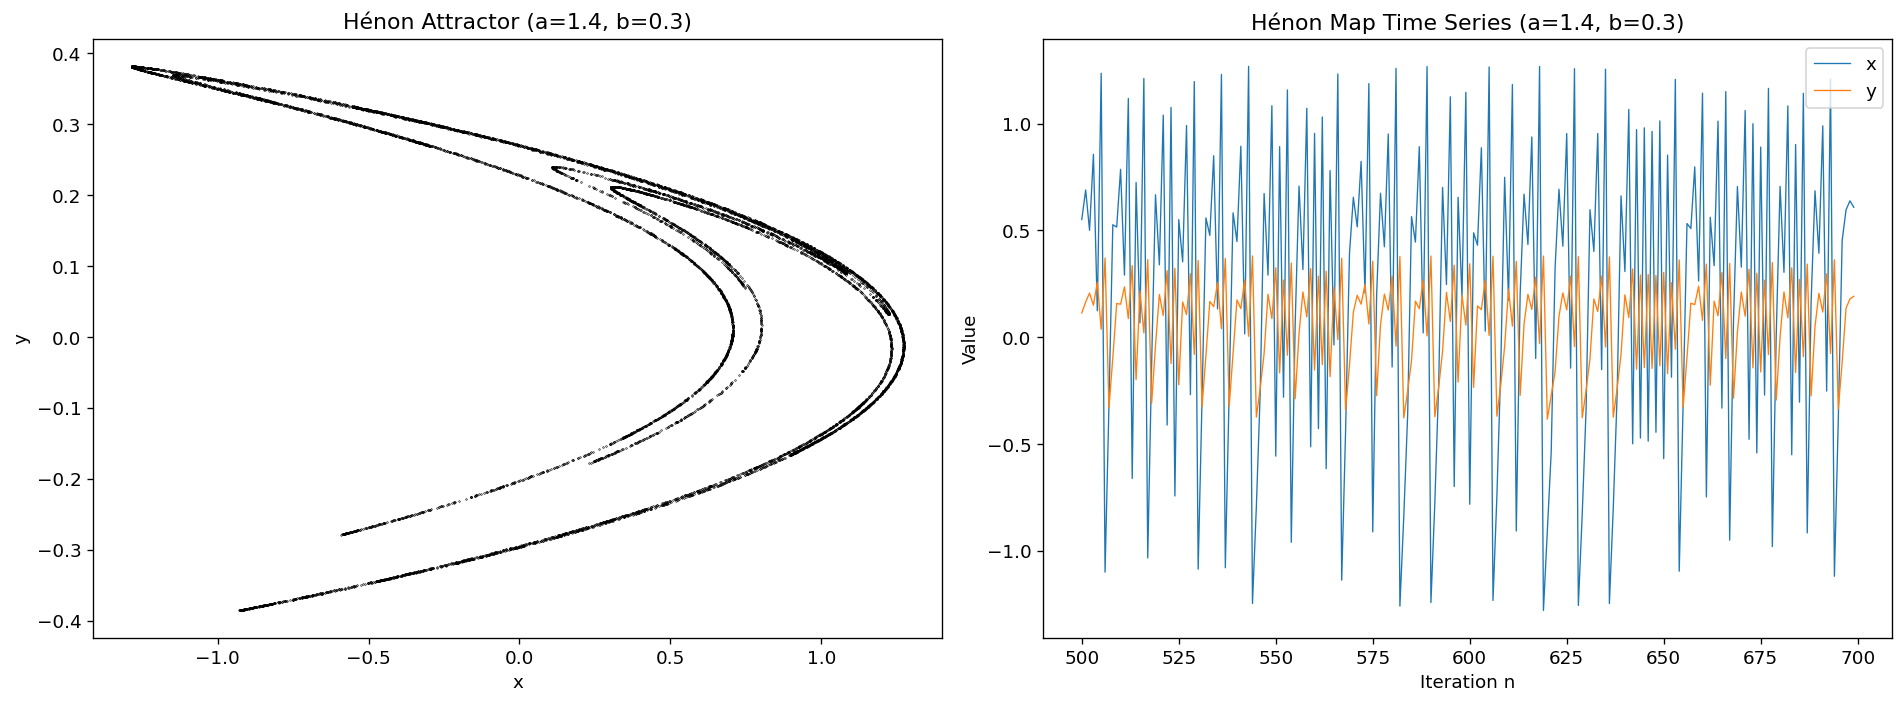

In [4]:
def henon_map(a, b, x0, y0, n):
    x, y = np.empty(n), np.empty(n)
    x[0], y[0] = x0, y0
    for i in range(1, n):
        x[i] = 1 - a * x[i-1]**2 + y[i-1]
        y[i] = b * x[i-1]
    return x, y

a, b, n, d = 1.4, 0.3, 10000, 500
hx, hy = henon_map(a, b, 0.0, 0.0, n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(hx[d:], hy[d:], s=0.1, c='black')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].set_title(f'Hénon Attractor (a={a}, b={b})')

axes[1].plot(range(d, d+200), hx[d:d+200], lw=0.8, label='x')
axes[1].plot(range(d, d+200), hy[d:d+200], lw=0.8, label='y')
axes[1].set_xlabel('Iteration n'); axes[1].set_ylabel('Value')
axes[1].set_title(f'Hénon Map Time Series (a={a}, b={b})')
axes[1].legend()

plt.tight_layout(); save('henon_attractor_timeseries'); plt.show()

## A.4 Hénon Map — Bifurcation Diagram
Sweep $a \in [1.0, 1.4]$ with $b = 0.3$ fixed. Fully vectorized.

Saved henon_bifurcation.png


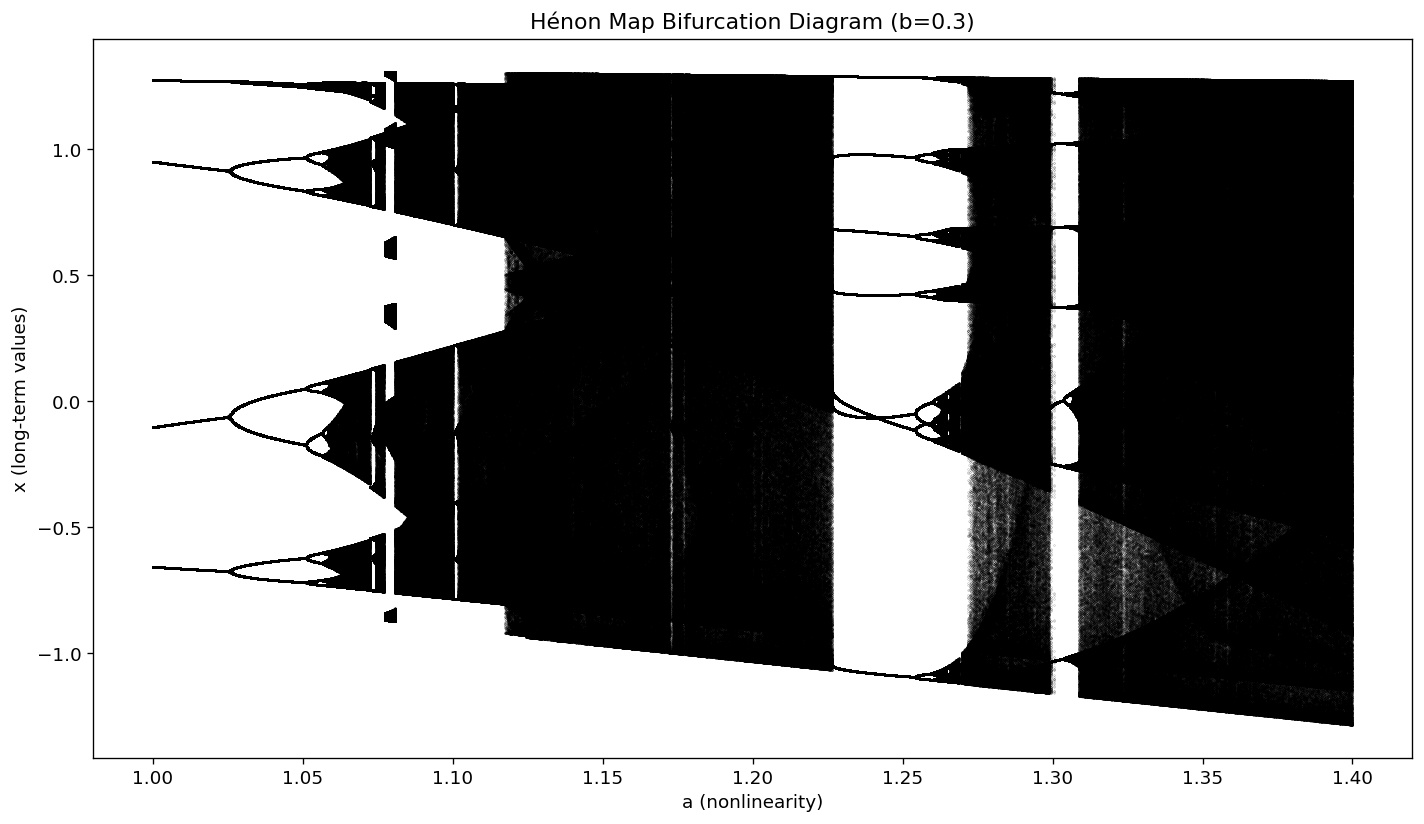

20.3s


In [5]:
t0 = time.time()
a_vals = np.linspace(1.0, 1.4, 2000)
b_fixed = 0.3
x = np.zeros_like(a_vals)
y = np.zeros_like(a_vals)
discard, keep = 500, 4500

for _ in range(discard):
    x_new = 1 - a_vals * x**2 + y
    y = b_fixed * x
    x = x_new

a_pts = np.empty(keep * len(a_vals))
x_pts = np.empty(keep * len(a_vals))
for i in range(keep):
    x_new = 1 - a_vals * x**2 + y
    y = b_fixed * x
    x = x_new
    finite = np.isfinite(x)
    start = i * len(a_vals)
    a_pts[start:start+len(a_vals)] = np.where(finite, a_vals, np.nan)
    x_pts[start:start+len(a_vals)] = np.where(finite, x, np.nan)

mask = np.isfinite(a_pts)
plt.figure(figsize=(12, 7))
plt.scatter(a_pts[mask], x_pts[mask], s=0.1, c='black', marker='.', alpha=0.5)
plt.xlabel('a (nonlinearity)'); plt.ylabel('x (long-term values)')
plt.title('Hénon Map Bifurcation Diagram (b=0.3)')
plt.tight_layout(); save('henon_bifurcation'); plt.show()
print(f'{time.time()-t0:.1f}s')

---
# Part B — Continuous Chaotic Systems
All systems integrated using `scipy.integrate.solve_ivp` with RK45 adaptive method.

## B.1 Lorenz System
$$\dot{x} = \sigma(y - x), \qquad \dot{y} = x(\rho - z) - y, \qquad \dot{z} = xy - \beta z$$

| Setting | Value |
|---|---|
| Parameters | $\sigma = 10,\ \rho = 28,\ \beta = 8/3$ |
| Initial condition | $(1, 1, 1)$ |
| Evaluation points | $dt = 0.01$, $T = 50$ |
| Solver | RK45 (`rtol=1e-10`, `atol=1e-12`) |

Saved lorenz_phase.png


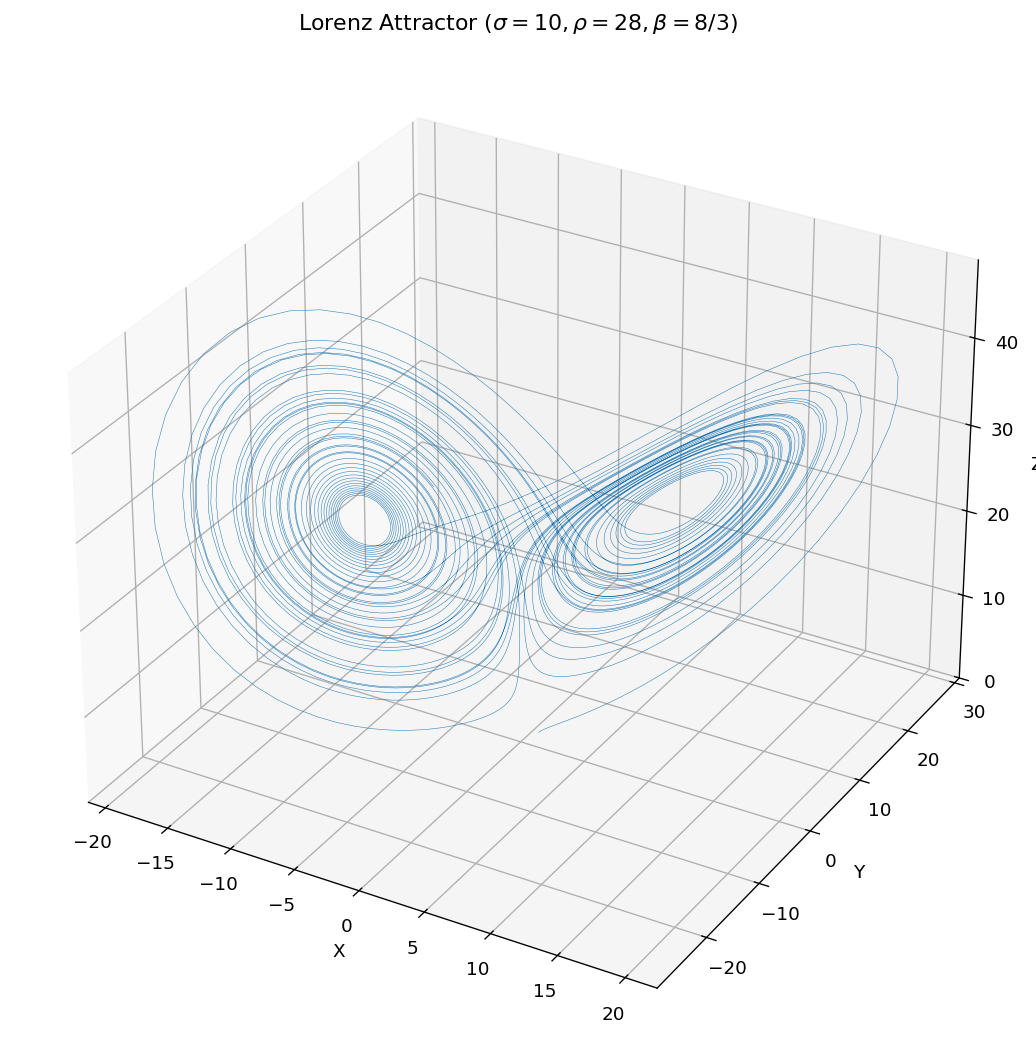

Saved lorenz_timeseries.png


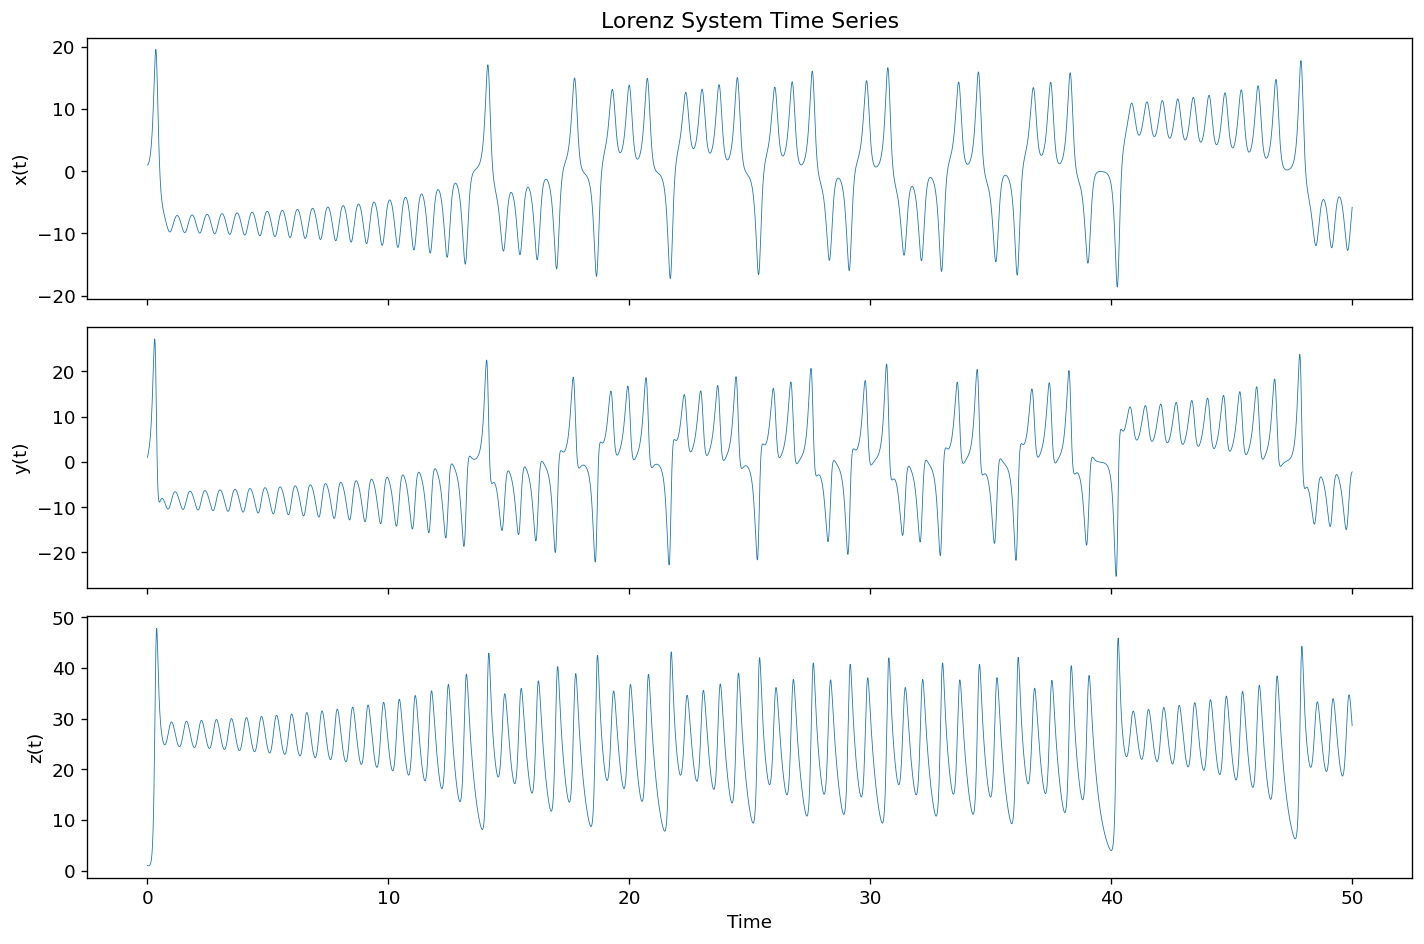

In [6]:
def lorenz(t, state, sigma=10, rho=28, beta=8/3):
    x, y, z = state
    return [sigma*(y-x), x*(rho-z)-y, x*y - beta*z]

sol = solve_ivp(lorenz, (0, 50), [1,1,1], method='RK45',
                t_eval=np.arange(0, 50, 0.01), rtol=1e-10, atol=1e-12)

# 3D phase space
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
ax.plot(sol.y[0], sol.y[1], sol.y[2], lw=0.3)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title(r'Lorenz Attractor ($\sigma=10, \rho=28, \beta=8/3$)')
plt.tight_layout(); save('lorenz_phase'); plt.show()

# Time series
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for i, (ax, lbl) in enumerate(zip(axes, ['x(t)','y(t)','z(t)'])):
    ax.plot(sol.t, sol.y[i], lw=0.5)
    ax.set_ylabel(lbl)
axes[-1].set_xlabel('Time')
axes[0].set_title('Lorenz System Time Series')
plt.tight_layout(); save('lorenz_timeseries'); plt.show()

## B.2 Rössler System
$$\dot{x} = -y - z, \qquad \dot{y} = x + ay, \qquad \dot{z} = b + z(x - c)$$

| Setting | Value |
|---|---|
| Parameters | $a = 0.2,\ b = 0.2,\ c = 5.7$ |
| Initial condition | $(1, 1, 1)$ |
| Evaluation points | $dt = 0.01$, $T = 300$ |
| Solver | RK45 |

Saved rossler_phase.png


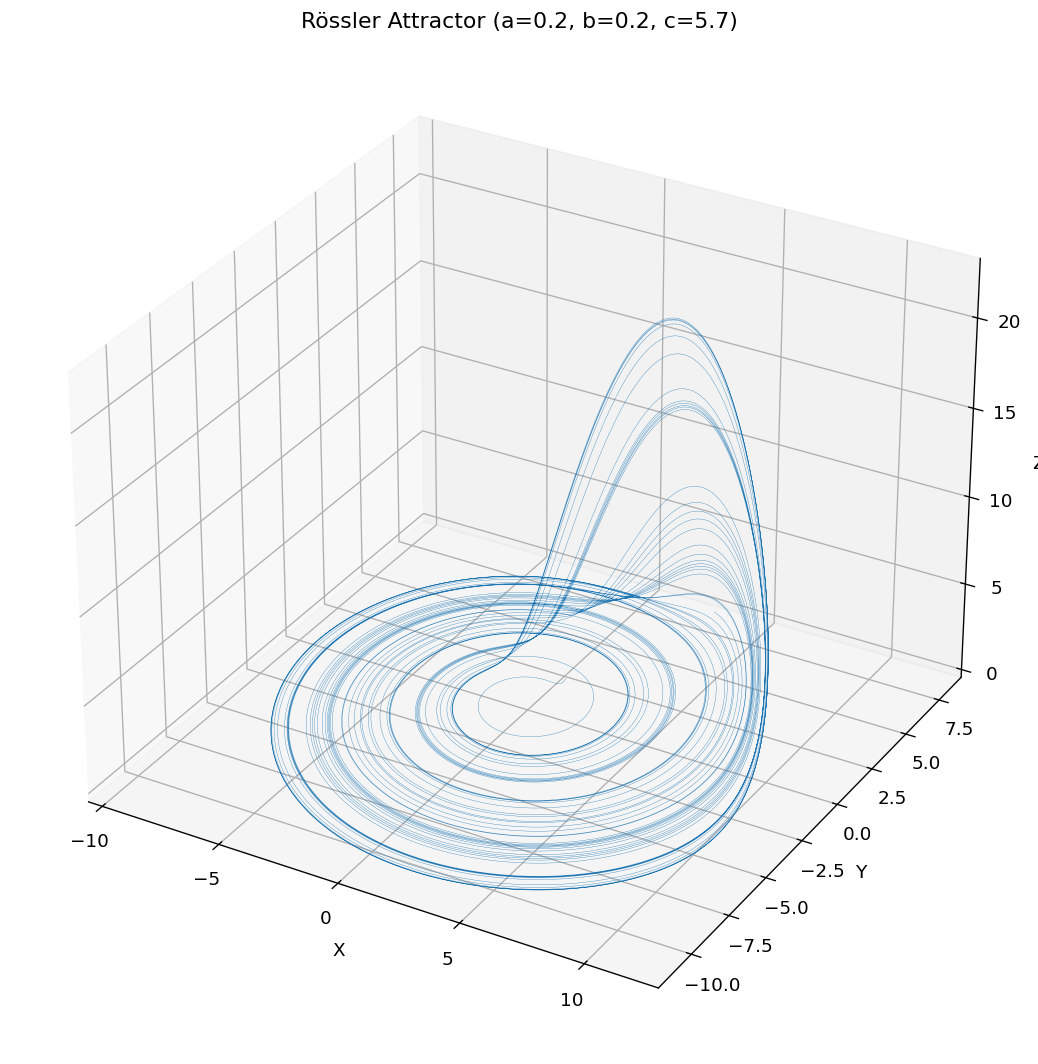

Saved rossler_timeseries.png


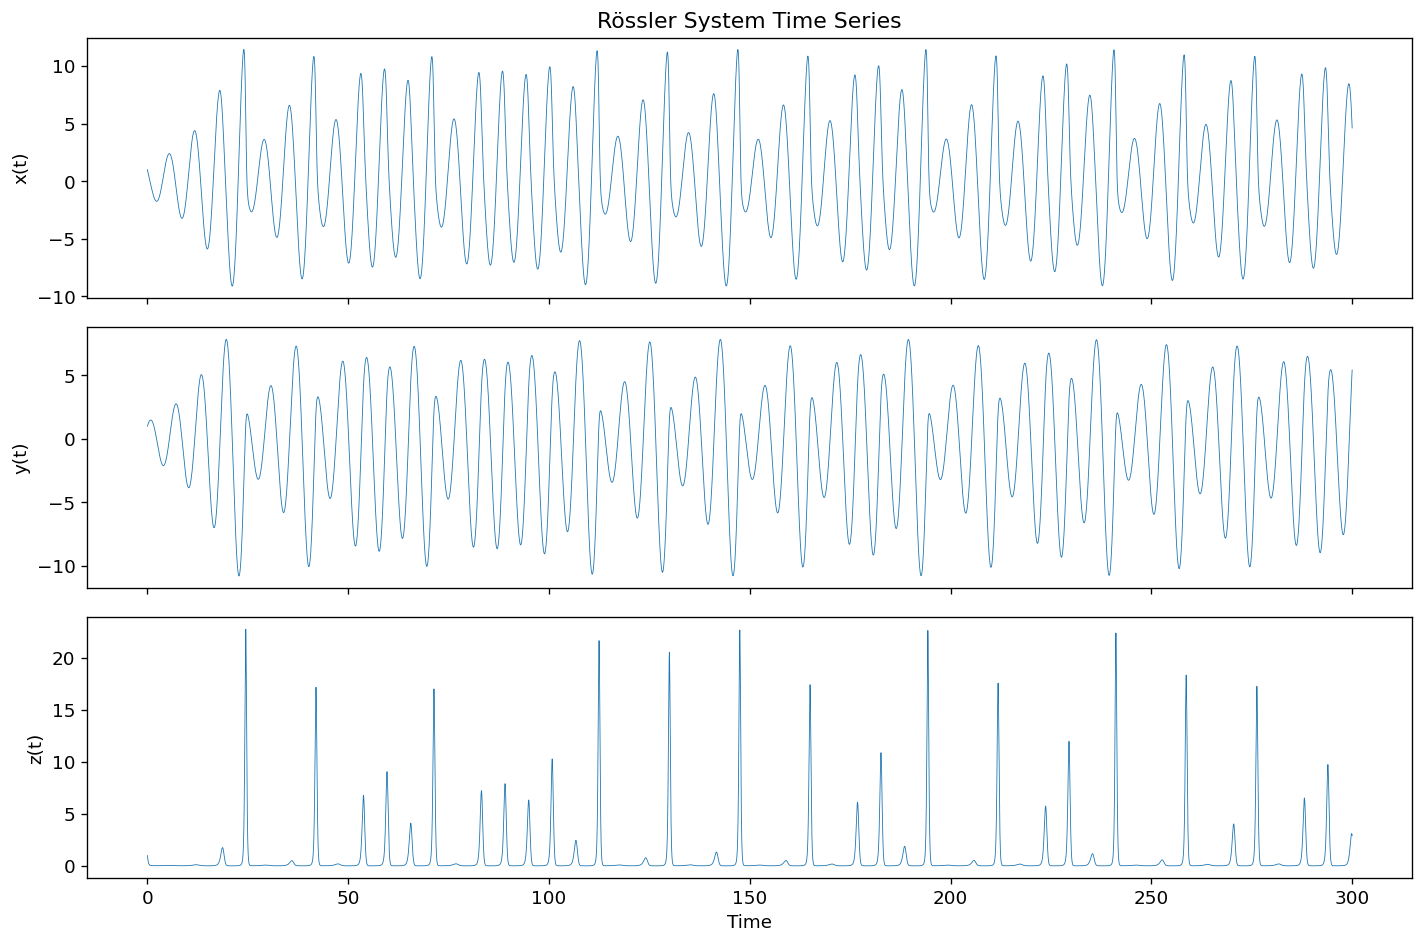

In [7]:
def rossler(t, state, a=0.2, b=0.2, c=5.7):
    x, y, z = state
    return [-y-z, x+a*y, b+z*(x-c)]

sol_r = solve_ivp(rossler, (0, 300), [1,1,1], method='RK45',
                  t_eval=np.arange(0, 300, 0.01), rtol=1e-10, atol=1e-12)

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
ax.plot(sol_r.y[0], sol_r.y[1], sol_r.y[2], lw=0.2)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('Rössler Attractor (a=0.2, b=0.2, c=5.7)')
plt.tight_layout(); save('rossler_phase'); plt.show()

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for i, (ax, lbl) in enumerate(zip(axes, ['x(t)','y(t)','z(t)'])):
    ax.plot(sol_r.t, sol_r.y[i], lw=0.5)
    ax.set_ylabel(lbl)
axes[-1].set_xlabel('Time')
axes[0].set_title('Rössler System Time Series')
plt.tight_layout(); save('rossler_timeseries'); plt.show()

## B.3 Chen System
$$\dot{x} = a(y - x), \qquad \dot{y} = (c - a)x - xz + cy, \qquad \dot{z} = xy - bz$$

| Setting | Value |
|---|---|
| Parameters | $a = 35,\ b = 3,\ c = 28$ |
| Initial condition | $(-0.1, 0.5, -0.6)$ |
| Evaluation points | $dt = 0.002$, $T = 50$ |
| Solver | RK45 |

Saved chen_phase.png


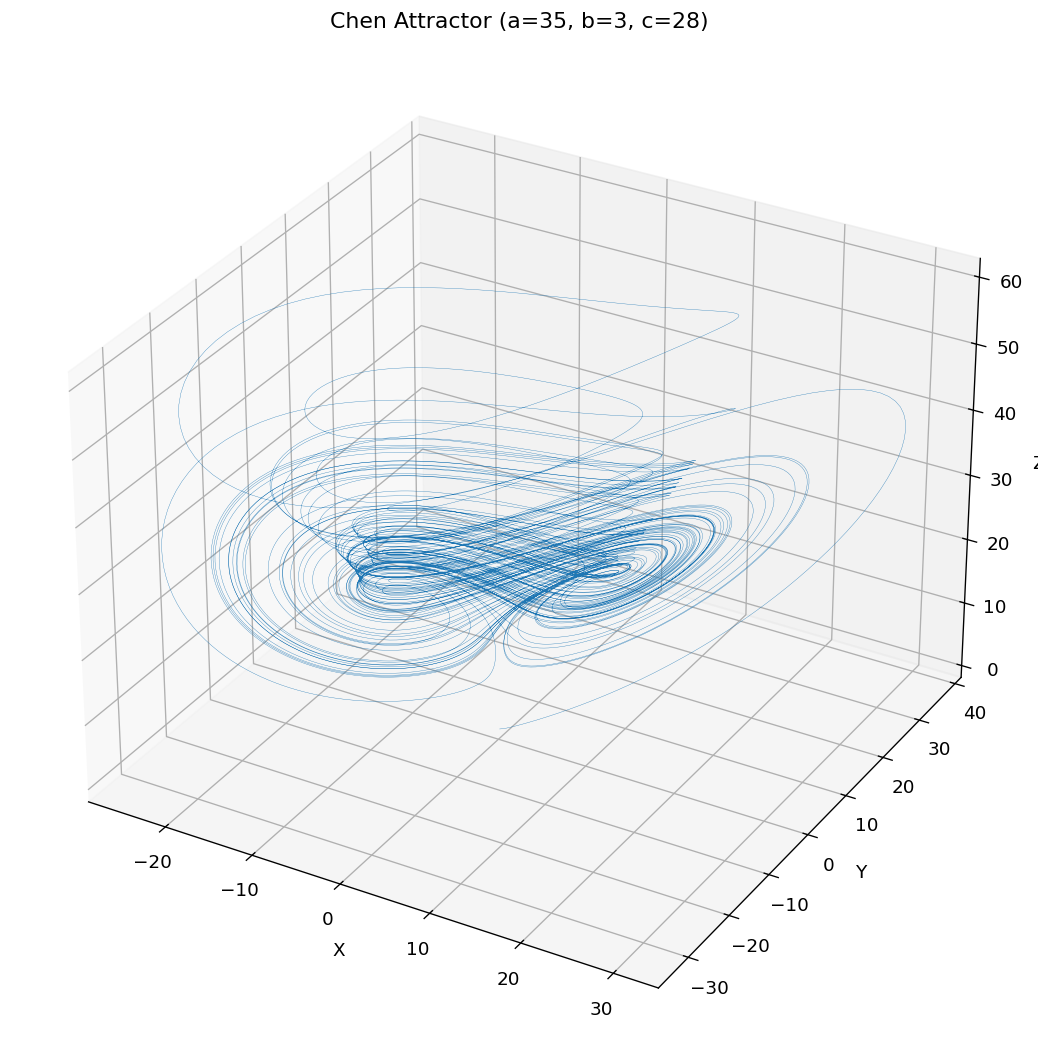

Saved chen_timeseries.png


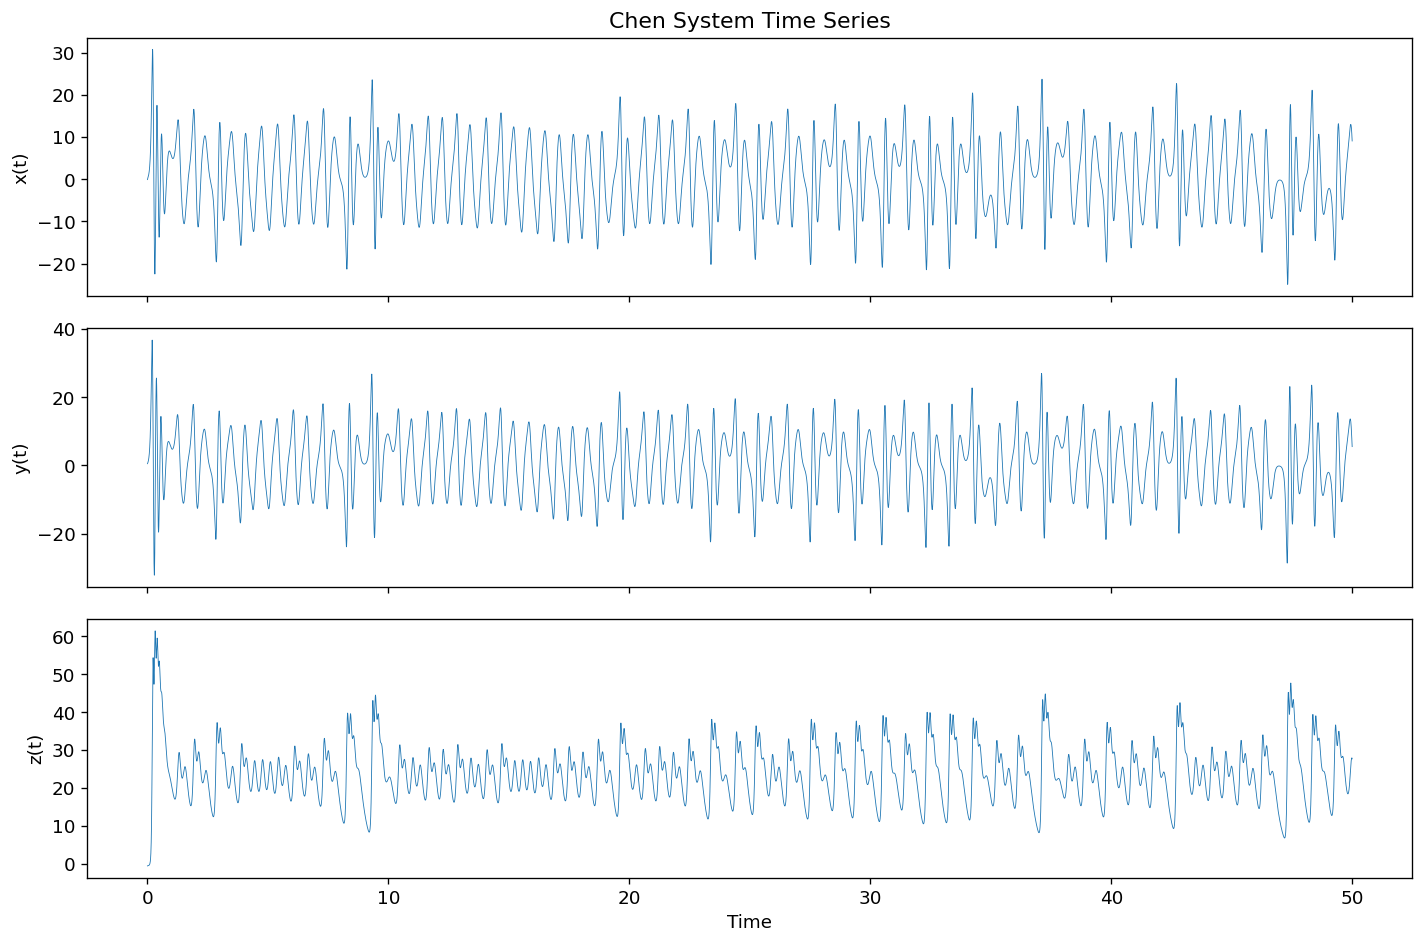

In [8]:
def chen(t, state, a=35, b=3, c=28):
    x, y, z = state
    return [a*(y-x), (c-a)*x - x*z + c*y, x*y - b*z]

sol_c = solve_ivp(chen, (0, 50), [-0.1, 0.5, -0.6], method='RK45',
                  t_eval=np.arange(0, 50, 0.002), rtol=1e-10, atol=1e-12)

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
ax.plot(sol_c.y[0], sol_c.y[1], sol_c.y[2], lw=0.2)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('Chen Attractor (a=35, b=3, c=28)')
plt.tight_layout(); save('chen_phase'); plt.show()

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for i, (ax, lbl) in enumerate(zip(axes, ['x(t)','y(t)','z(t)'])):
    ax.plot(sol_c.t, sol_c.y[i], lw=0.5)
    ax.set_ylabel(lbl)
axes[-1].set_xlabel('Time')
axes[0].set_title('Chen System Time Series')
plt.tight_layout(); save('chen_timeseries'); plt.show()

## B.4 Hyperchaotic Rössler System
$$\dot{x} = -y - z, \quad \dot{y} = x + ay + w, \quad \dot{z} = b + xz, \quad \dot{w} = -cz + dw$$

| Setting | Value |
|---|---|
| Parameters | $a = 0.25,\ b = 3,\ c = 0.5,\ d = 0.05$ |
| Initial condition | $(-10, -6, 0, 10)$ |
| Evaluation points | $dt = 0.01$, $T = 250$ |
| Solver | RK45 |

Saved hyper_rossler_projections.png


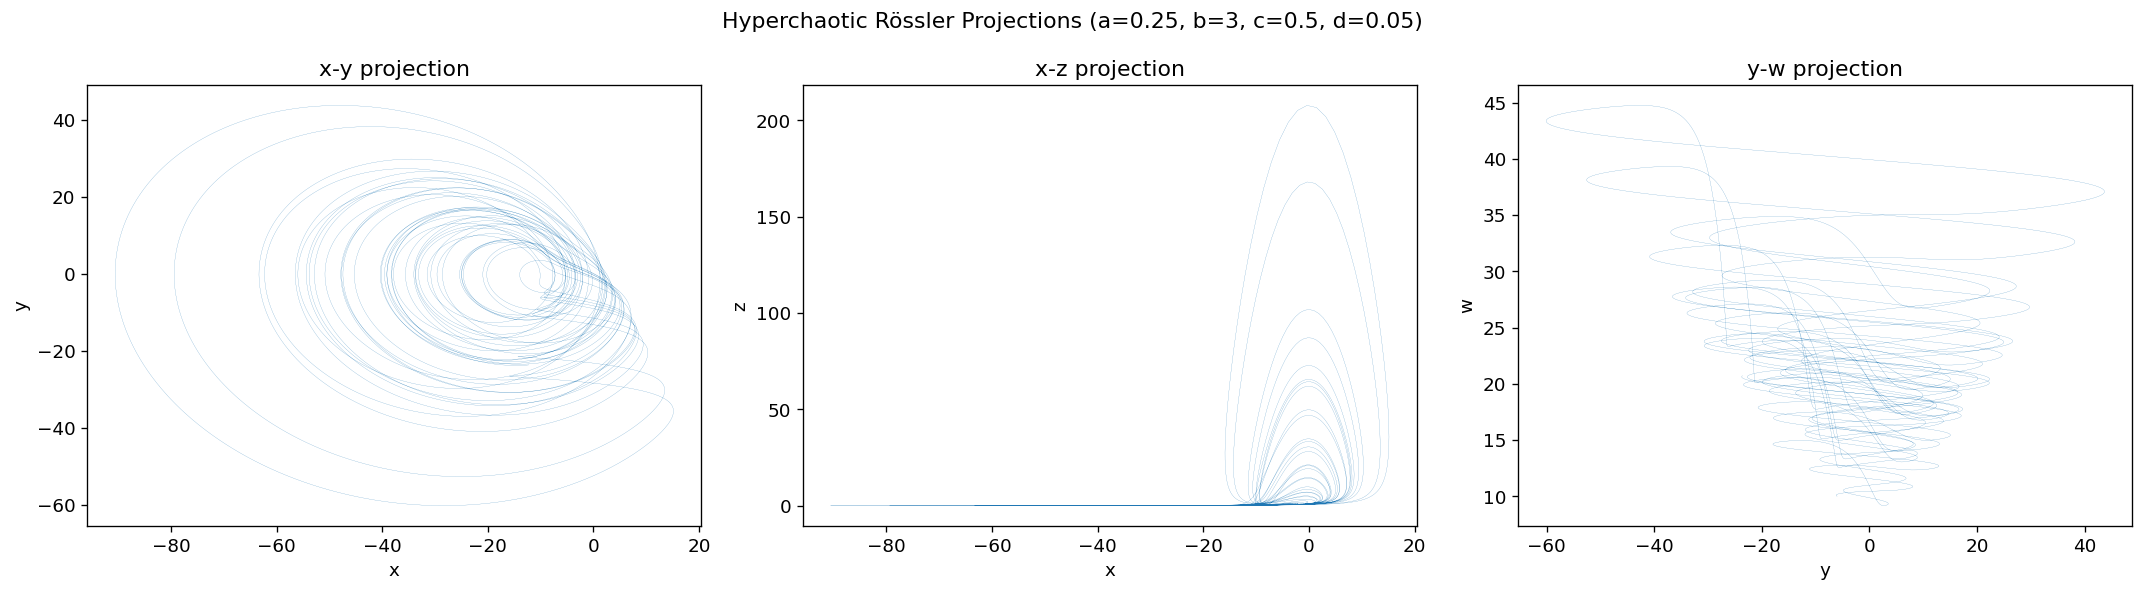

Saved hyper_rossler_timeseries.png


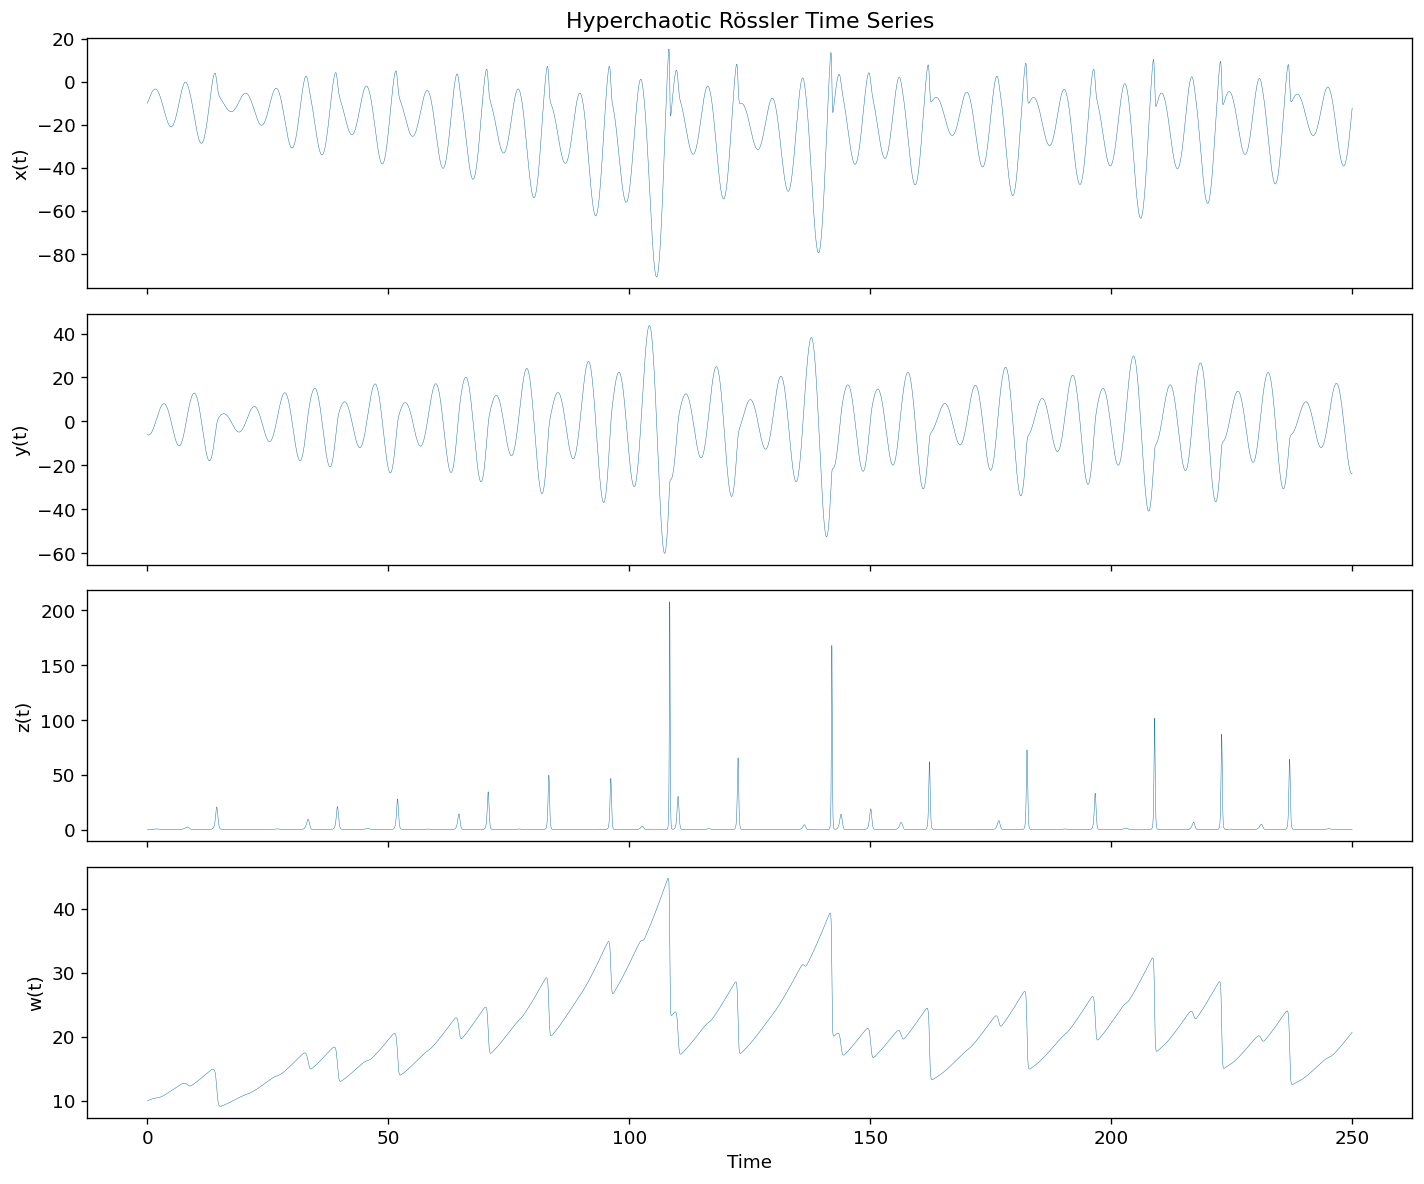

In [9]:
def hyper_rossler(t, state, a=0.25, b=3, c=0.5, d=0.05):
    x, y, z, w = state
    return [-y-z, x+a*y+w, b+x*z, -c*z+d*w]

sol_hr = solve_ivp(hyper_rossler, (0, 250), [-10,-6,0,10], method='RK45',
                   t_eval=np.arange(0, 250, 0.01), rtol=1e-10, atol=1e-12)

# 2D/3D projections
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (i,j,xl,yl) in zip(axes, [(0,1,'x','y'),(0,2,'x','z'),(1,3,'y','w')]):
    ax.plot(sol_hr.y[i], sol_hr.y[j], lw=0.1)
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_title(f'{xl}-{yl} projection')
plt.suptitle('Hyperchaotic Rössler Projections (a=0.25, b=3, c=0.5, d=0.05)')
plt.tight_layout(); save('hyper_rossler_projections'); plt.show()

# Time series
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
for i, (ax, lbl) in enumerate(zip(axes, ['x(t)','y(t)','z(t)','w(t)'])):
    ax.plot(sol_hr.t, sol_hr.y[i], lw=0.3)
    ax.set_ylabel(lbl)
axes[-1].set_xlabel('Time')
axes[0].set_title('Hyperchaotic Rössler Time Series')
plt.tight_layout(); save('hyper_rossler_timeseries'); plt.show()

---
# Part C — Sensitivity Analysis
## C.1 Parameter Sweep: Lorenz $\rho$-Sweep
For each $\rho \in [0, 30]$ ($\sigma = 10$, $\beta = 8/3$ fixed), integrate the Lorenz system, discard transient ($t < 20$), record local maxima of $z(t)$.

Saved lorenz_rho_sweep.png


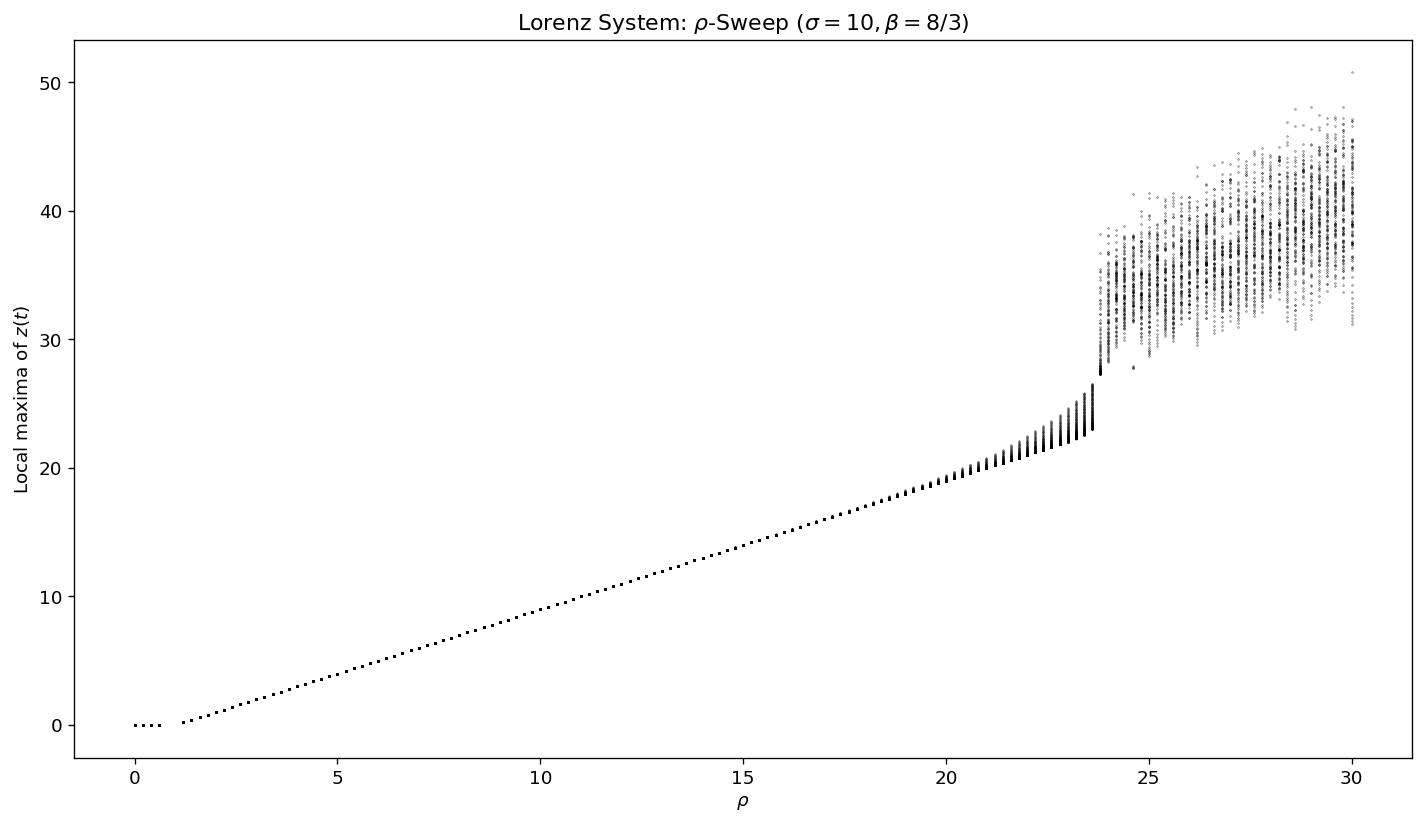

41.9s


In [10]:
t0 = time.time()
rho_values = np.arange(0, 30.1, 0.2)

all_rho = []
all_zmax = []

for rho in rho_values:
    sol_s = solve_ivp(lorenz, (0, 100), [1,1,1], method='RK45',
                      args=(10, rho, 8/3), dense_output=False,
                      rtol=1e-8, atol=1e-8)
    z = sol_s.y[2]
    t = sol_s.t
    mask = t > 20
    z = z[mask]
    
    if len(z) > 2:
        idx = (z[1:-1] > z[:-2]) & (z[1:-1] > z[2:])
        maxima = z[1:-1][idx]
        if len(maxima) > 0:
            all_rho.extend([rho] * len(maxima))
            all_zmax.extend(maxima)

plt.figure(figsize=(12, 7))
plt.scatter(all_rho, all_zmax, s=0.5, c='black', marker='.', alpha=0.6)
plt.xlabel(r'$\rho$'); plt.ylabel(r'Local maxima of $z(t)$')
plt.title(r'Lorenz System: $\rho$-Sweep ($\sigma=10, \beta=8/3$)')
plt.tight_layout(); save('lorenz_rho_sweep'); plt.show()
print(f'{time.time()-t0:.1f}s')

## C.2 Step-Size Sensitivity
Re-simulate Lorenz at standard chaotic parameters using **fixed-step RK4** with three step sizes ($dt = 0.001, 0.01, 0.05$). A fixed-step solver ensures $dt$ directly controls integration accuracy — adaptive RK45 would pick its own internal steps regardless of `t_eval`.

Integration: 1.5s
Saved stepsize_xt_overlay.png


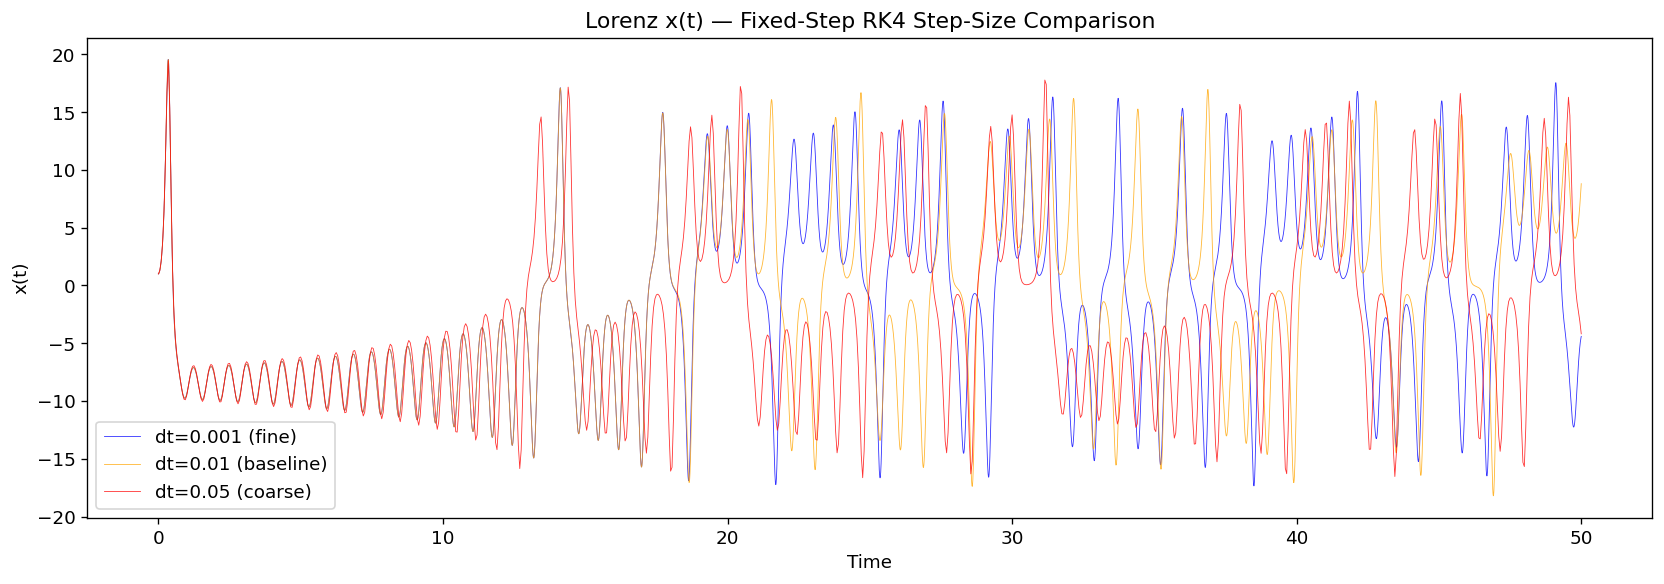

In [ ]:
def rk4(f, y0, t_span, dt):
    """Fixed-step RK4 integrator."""
    t = np.arange(t_span[0], t_span[1] + dt/2, dt)
    n = len(t)
    y = np.zeros((len(y0), n))
    y[:, 0] = y0
    for i in range(n - 1):
        ti, yi = t[i], y[:, i]
        k1 = np.array(f(ti, yi))
        k2 = np.array(f(ti + dt/2, yi + dt/2*k1))
        k3 = np.array(f(ti + dt/2, yi + dt/2*k2))
        k4 = np.array(f(ti + dt, yi + dt*k3))
        y[:, i+1] = yi + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)
    return t, y

t0 = time.time()
dt_vals = [0.001, 0.01, 0.05]
colors = ['blue', 'orange', 'red']
labels = ['dt=0.001 (fine)', 'dt=0.01 (baseline)', 'dt=0.05 (coarse)']
sols = {}

for dt in dt_vals:
    sols[dt] = rk4(lorenz, [1.0, 1.0, 1.0], (0, 50), dt)

print(f'Integration: {time.time()-t0:.1f}s')

# (i) x(t) overlay
plt.figure(figsize=(14, 5))
for dt, c, lbl in zip(dt_vals, colors, labels):
    t, y = sols[dt]
    plt.plot(t, y[0], lw=0.5, color=c, label=lbl, alpha=0.8)
plt.xlabel('Time'); plt.ylabel('x(t)')
plt.title('Lorenz x(t) — Fixed-Step RK4 Step-Size Comparison')
plt.legend(); plt.tight_layout(); save('stepsize_xt_overlay'); plt.show()

Saved stepsize_phase_overlay.png


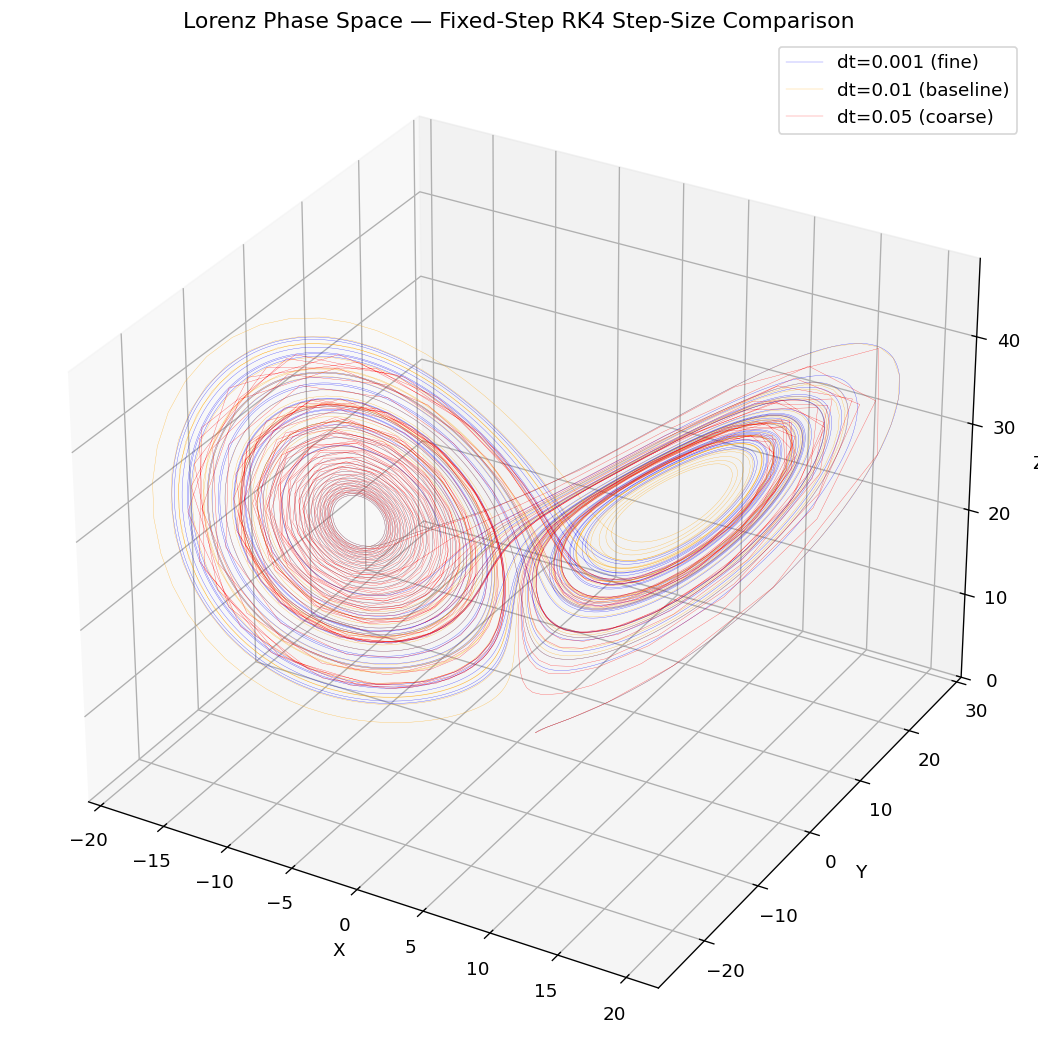

Saved stepsize_divergence.png


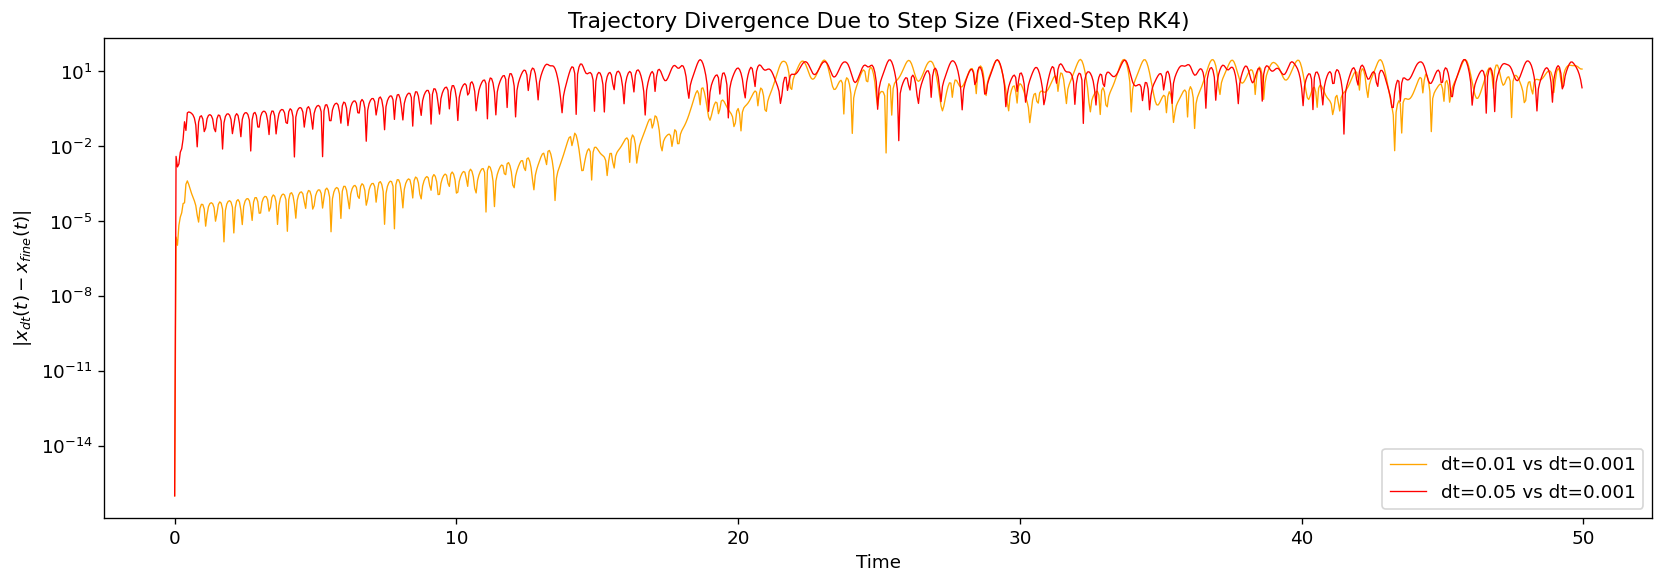

In [12]:
# (ii) 3D phase space overlay
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
for dt, c, lbl in zip(dt_vals, colors, labels):
    t, y = sols[dt]
    ax.plot(y[0], y[1], y[2], lw=0.2, color=c, label=lbl, alpha=0.7)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('Lorenz Phase Space — Fixed-Step RK4 Step-Size Comparison')
ax.legend(); plt.tight_layout(); save('stepsize_phase_overlay'); plt.show()

# (iii) Divergence plot
t_fine, y_fine = sols[0.001]
plt.figure(figsize=(14, 5))
for dt, c, lbl in zip([0.01, 0.05], ['orange','red'],
                       ['dt=0.01 vs dt=0.001', 'dt=0.05 vs dt=0.001']):
    t_dt, y_dt = sols[dt]
    t_common = np.arange(0, 50, 0.05)
    x_interp = np.interp(t_common, t_dt, y_dt[0])
    x_ref = np.interp(t_common, t_fine, y_fine[0])
    div = np.abs(x_interp - x_ref)
    div[div == 0] = 1e-16
    plt.plot(t_common, div, lw=0.8, color=c, label=lbl)
plt.xlabel('Time'); plt.ylabel(r'$|x_{dt}(t) - x_{fine}(t)|$')
plt.title('Trajectory Divergence Due to Step Size (Fixed-Step RK4)')
plt.yscale('log'); plt.legend()
plt.tight_layout(); save('stepsize_divergence'); plt.show()

---
# Summary of Generated Figures

In [13]:
figs = sorted(os.listdir(FIGURES_DIR))
print(f'Generated {len(figs)} figures in {FIGURES_DIR}/:')
for f in figs:
    size = os.path.getsize(f'{FIGURES_DIR}/{f}') / 1024
    print(f'  {f:40s} {size:6.0f} KB')

Generated 16 figures in ../Figures/:
  chen_phase.png                              776 KB
  chen_timeseries.png                         507 KB
  henon_attractor_timeseries.png              541 KB
  henon_bifurcation.png                       633 KB
  hyper_rossler_projections.png               472 KB
  hyper_rossler_timeseries.png                324 KB
  logistic_bifurcation.png                   1201 KB
  logistic_timeseries.png                     796 KB
  lorenz_phase.png                            854 KB
  lorenz_rho_sweep.png                        140 KB
  lorenz_timeseries.png                       431 KB
  rossler_phase.png                           744 KB
  rossler_timeseries.png                      427 KB
  stepsize_divergence.png                     202 KB
  stepsize_phase_overlay.png                 1180 KB
  stepsize_xt_overlay.png                     447 KB
